<a href="https://colab.research.google.com/github/docarmorafael/engenharia_de_prompt_aplicacoes_ai/blob/main/aula08_AutomacaoAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 08: Automação com AI

Nome: João Rafael (Turma de sexta-feira)

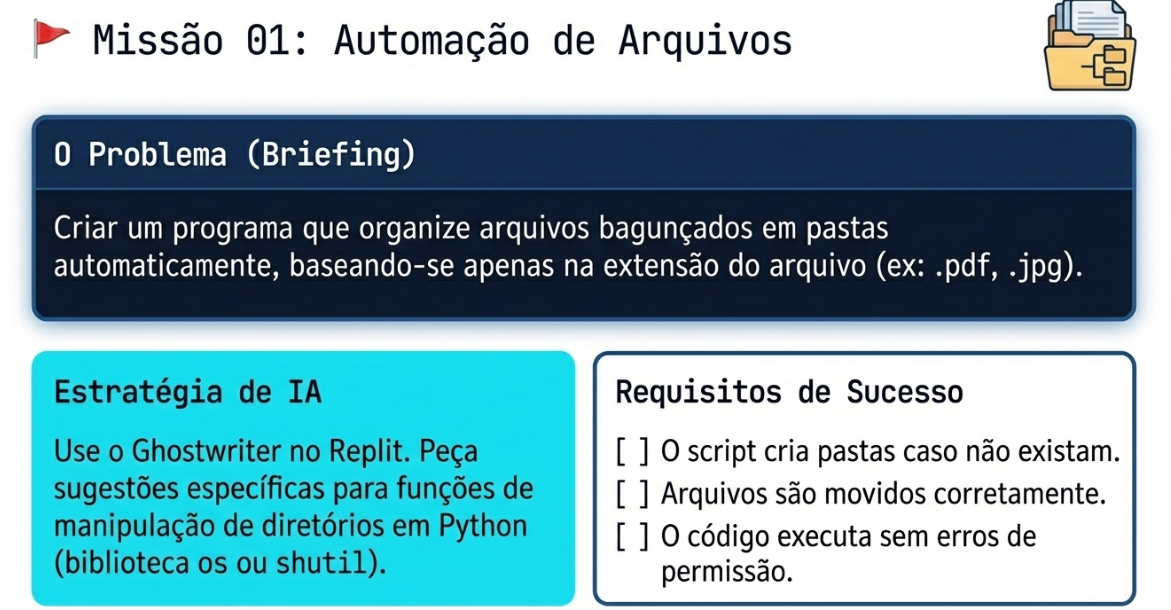

In [ ]:
import os
import shutil

# Define diretórios de origem e destino
source_dir = "arquivos_baguncados"
destination_root_dir = "arquivos_organizados"

# Cria o diretório de origem se ele não existir
os.makedirs(source_dir, exist_ok=True)

# Lista de arquivos fictícios para simular um diretório bagunçado
dummy_files = {
    "documento1.pdf": source_dir,
    "imagem1.jpg": source_dir,
    "relatorio.docx": source_dir,
    "dados.xlsx": source_dir,
    "foto.png": source_dir,
    "apresentacao.pptx": source_dir,
    "script.py": source_dir,
    "backup.zip": source_dir,
    "musica.mp3": source_dir,
    "video.mp4": source_dir,
    "documento2.pdf": source_dir,
    "imagem2.jpeg": source_dir,
    "texto.txt": source_dir,
    "arquivo_sem_extensao": source_dir
}

# Cria os arquivos fictícios no diretório de origem
for filename, path in dummy_files.items():
    file_path = os.path.join(path, filename)
    if not os.path.exists(file_path):
        with open(file_path, "w") as f:
            f.write("Conteúdo de teste")

# Cria o diretório raiz de destino se ele não existir
os.makedirs(destination_root_dir, exist_ok=True)

# Obtém uma lista de todos os arquivos no diretório de origem
files_to_organize = [f for f in os.listdir(source_dir) if os.path.isfile(os.path.join(source_dir, f))]

# Dicionário para armazenar os arquivos movidos por diretório
moved_files_info = {}

# Itera sobre cada arquivo e o organiza em uma pasta baseada na extensão
for filename in files_to_organize:
    file_path = os.path.join(source_dir, filename)

    # Separa o nome do arquivo da extensão
    _, file_extension = os.path.splitext(filename)

    # Remove o '.' da extensão e converte para minúsculas
    file_extension = file_extension[1:].lower()

    # Define o diretório de destino: 'sem_extensao' se não houver extensão,
    # ou a extensão do arquivo
    if not file_extension:
        target_dir_name = "sem_extensao"
    else:
        target_dir_name = file_extension

    target_dir = os.path.join(destination_root_dir, target_dir_name)

    # Cria o diretório de destino se ele não existir
    os.makedirs(target_dir, exist_ok=True)

    # Move o arquivo para o diretório de destino
    shutil.move(file_path, os.path.join(target_dir, filename))

    # Registra o arquivo movido
    if target_dir_name not in moved_files_info:
        moved_files_info[target_dir_name] = []
    moved_files_info[target_dir_name].append(filename)

# Imprime os arquivos que foram movidos para cada pasta
print("\n--- Detalhes da Organização ---")
for folder, files in moved_files_info.items():
    print("Pasta '" + folder + "':")
    for file in files:
        print("  - " + file)

# Imprime uma mensagem de conclusão usando concatenação de strings
print("\nArquivos organizados de '" + source_dir + "' para '" + destination_root_dir + "'.")
print("Organização concluída!")


--- Detalhes da Organização ---
Pasta 'png':
  - foto.png
Pasta 'mp4':
  - video.mp4
Pasta 'pdf':
  - documento1.pdf
  - documento2.pdf
Pasta 'docx':
  - relatorio.docx
Pasta 'zip':
  - backup.zip
Pasta 'mp3':
  - musica.mp3
Pasta 'sem_extensao':
  - arquivo_sem_extensao
Pasta 'jpeg':
  - imagem2.jpeg
Pasta 'xlsx':
  - dados.xlsx
Pasta 'py':
  - script.py
Pasta 'jpg':
  - imagem1.jpg
Pasta 'txt':
  - texto.txt
Pasta 'pptx':
  - apresentacao.pptx

Arquivos organizados de 'arquivos_baguncados' para 'arquivos_organizados'.
Organização concluída!


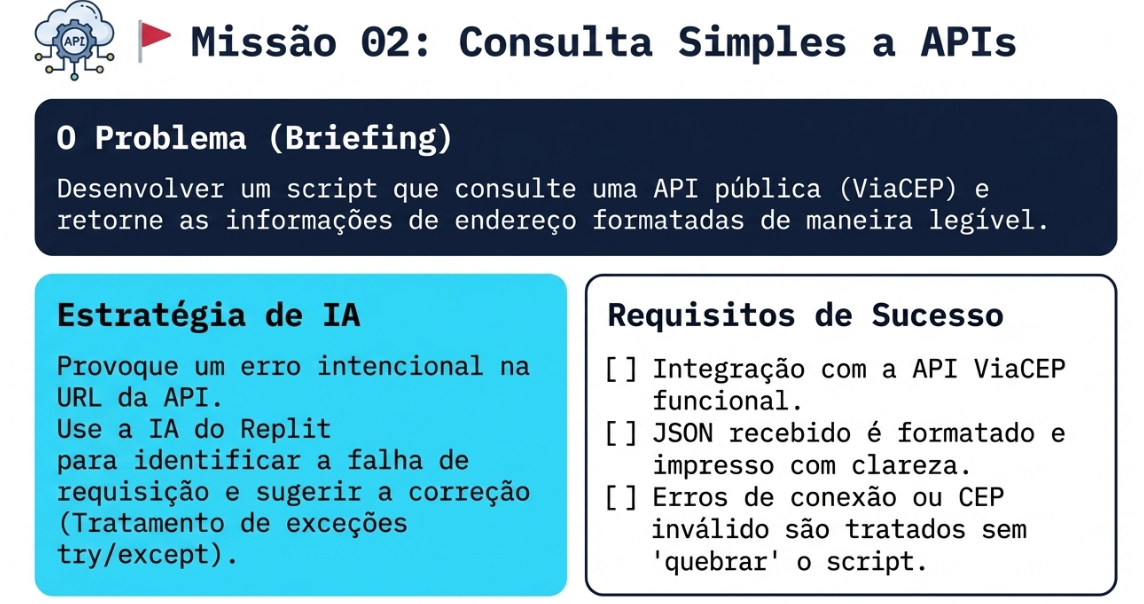

### Consulta à API ViaCEP

Este script permite consultar informações de endereço a partir de um CEP utilizando a API ViaCEP.

In [1]:
import requests # Importa a biblioteca requests para fazer requisições HTTP

# Solicita ao usuário que digite o CEP e armazena na variável 'cep'
cep = input("Digite o CEP (somente números): ")

# Constrói a URL da API ViaCEP usando concatenação de strings
url = "https://viacep.com.br/ws/" + cep + "/json/"

try:
    # Faz a requisição GET para a API ViaCEP
    response = requests.get(url)
    # Lança uma exceção se a requisição retornar um status de erro (4xx ou 5xx)
    response.raise_for_status()
    # Converte a resposta JSON em um dicionário Python
    data = response.json()

    # Verifica se a resposta contém a chave 'erro', indicando que o CEP não foi encontrado
    if 'erro' in data:
        print("CEP não encontrado ou inválido.")
    else:
        # Imprime as informações do endereço formatadas, usando concatenação de strings
        print("\nEndereço para o CEP " + cep + ":")
        print("  Logradouro: " + str(data.get('logradouro')))
        print("  Complemento: " + str(data.get('complemento')))
        print("  Bairro: " + str(data.get('bairro')))
        print("  Cidade: " + str(data.get('localidade')))
        print("  Estado: " + str(data.get('uf')))
        print("  DDD: " + str(data.get('ddd')))

# Captura exceções relacionadas a problemas na requisição (ex: falha de conexão)
except requests.exceptions.RequestException as e:
    print("Erro ao fazer a requisição: " + str(e))
# Captura exceções se houver um problema ao decodificar a resposta JSON
except ValueError:
    print("Erro ao decodificar a resposta JSON.")

Digite o CEP (somente números): 71805772

Endereço para o CEP 71805772:
  Logradouro: Quadra QOF QN 7 Conjunto 1
  Complemento: 
  Bairro: Riacho Fundo I
  Cidade: Brasília
  Estado: DF
  DDD: 61


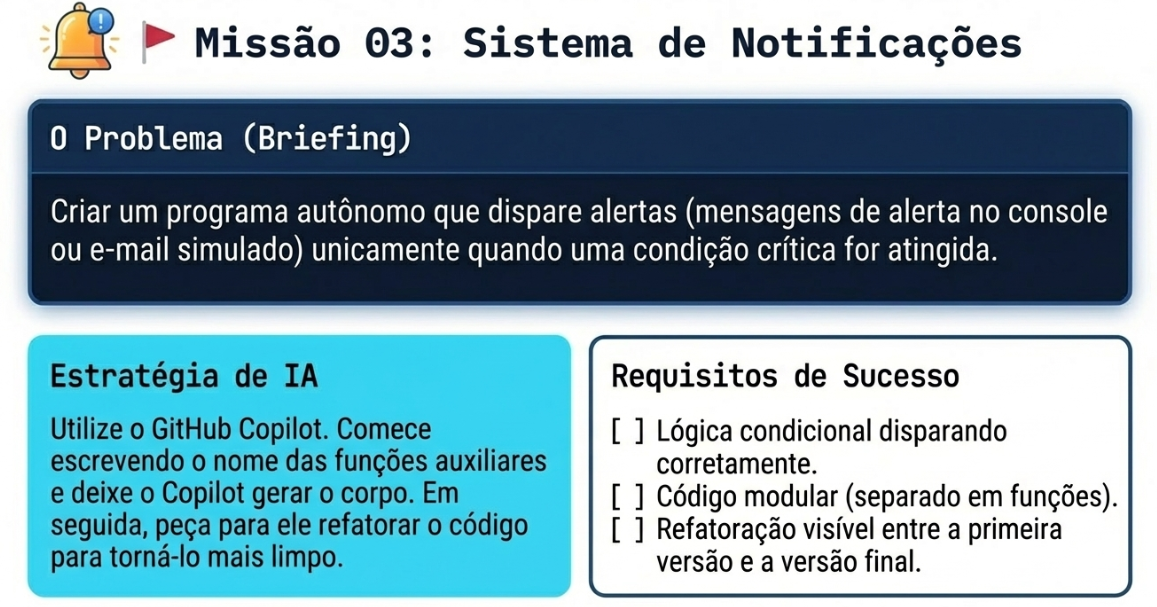

### Programa Autônomo para Alertas Críticos

Este programa simula um sistema de monitoramento que verifica continuamente uma condição e dispara um alerta (via console) se a condição crítica for atingida. Ele representa um conceito básico para automação de resposta a eventos importantes.

In [ ]:
import time # Mantido: Importa a biblioteca 'time' para usar a função sleep
import random # Mantido: Importa a biblioteca 'random' para simular valores aleatórios

def check_critical_condition(value, threshold):
    # Mantido: Função que verifica se um valor excede um limite
    return value > threshold

def trigger_alert(message):
    # Alterado: Substituído f-string por concatenação para imprimir a mensagem de alerta
    print("ALERTA CRÍTICO: " + message)


threshold = 80 # Mantido: Define o limite crítico para o alerta
monitoring_interval_seconds = 2 # Mantido: Define o intervalo de monitoramento em segundos

# Mantido: Imprime mensagem inicial do monitoramento
print("Iniciando monitoramento autônomo...")
# Alterado: Substituído f-string por concatenação para imprimir o limite
print("Alerta será disparado se o valor simulado exceder " + str(threshold))

while True:
    # Mantido: Simula um valor aleatório entre 0 e 100
    simulated_value = random.randint(0, 100)
    # Alterado: Substituído f-string por concatenação para imprimir o valor atual
    print("Valor atual: " + str(simulated_value))

    # Mantido: Verifica se a condição crítica foi atingida
    if check_critical_condition(simulated_value, threshold):
        # Alterado: Substituído f-string por concatenação na mensagem do alerta
        trigger_alert("Valor (" + str(simulated_value) + ") ultrapassou o limite crítico de " + str(threshold) + "!")

    # Mantido: Pausa a execução pelo tempo definido
    # Corrigido: Nome da variável de tempo de espera estava incorreto, "monitoring_interval_interval_seconds" para "monitoring_interval_seconds"
    time.sleep(monitoring_interval_seconds)

Iniciando monitoramento autônomo...
Alerta será disparado se o valor simulado exceder 80
Valor atual: 40
Valor atual: 62
Valor atual: 25
Valor atual: 85
ALERTA CRÍTICO: Valor (85) ultrapassou o limite crítico de 80!
Valor atual: 58
Valor atual: 95
ALERTA CRÍTICO: Valor (95) ultrapassou o limite crítico de 80!
Valor atual: 37
Valor atual: 5
Valor atual: 24
Valor atual: 35


KeyboardInterrupt: 